## Содержание:
* [Знакомство с Pandas](#pandas)
* [Графическое представление и описание поведения временного ряда](#first_first-bullet)
   * [Выделение закономерных (неслучайных) составляющих временного ряда](#second-bullet)
   * [Стационарность](#stacionary)
   * [Тренд](#trend)
   * [Выбросы](#out)
   * [Сезонность](#season)
* [Сглаживание и фильтрация](#filtre)
* [Автокорреляция и коррелограмма](#autocor)

### Знакомство с Pandas <a class="anchor" id="pandas"></a>

Встречайте библиотеку, которая позволяет комфортно обрабатывать и анализировать данные - Pandas!

In [32]:
!pip install pandas
!pip install statsmodels

In [33]:
# Импортируем необходимые библиотеки

import os
from os import path
from matplotlib import pyplot as plt
import pandas as pd

Мы будем работать с двумя рядами - нефильтрованной записью ЭКГ и записями о пассажиропотоке.

Импортируем необходимые данные

In [35]:
# с помощью системной библиотеки OS определяем путь до файла с данными ЭКГ
dirname = os.path.abspath(os.curdir) + r'\data'
# загружаем данные в переменную, содержащую объект библиотеки Pandas - Dataframe
tsdf_c = pd.read_csv(path.join(os.sep, dirname, 'agriculture_dataset_with_target.csv'))
# устанавливаем индекс времени для временного ряда и сортируем по нему выборку
tsdf_c.set_index('Timestamp').sort_index()


,Record_ID,Soil_Moisture,Soil_Temperature,Soil_pH,Humidity,Air_Temperature,Solar_Radiation,Wind_Speed,NDVI_Index,5G_Latency_ms,Crop_Health
Timestamp,,,,,,,,,,,
2024-01-01 00:00:00,1,19.98,16.54,6.93,72.14,33.01,498.91,6.61,0.255,1.04,Healthy
2024-01-01 01:00:00,2,43.03,16.17,7.51,41.21,32.18,466.33,0.98,0.267,1.00,High_Stress
2024-01-01 02:00:00,3,34.28,32.66,7.40,86.71,17.39,340.92,2.57,0.689,5.25,Healthy
2024-01-01 03:00:00,4,28.95,16.24,5.88,69.85,38.06,685.81,7.78,0.565,1.26,High_Stress
2024-01-01 04:00:00,5,11.24,16.80,5.87,40.22,29.21,581.30,5.38,0.793,9.77,Healthy
...,...,...,...,...,...,...,...,...,...,...,...
2024-03-24 03:00:00,1996,31.28,21.05,7.21,47.76,36.44,203.72,4.36,0.206,6.60,Healthy
2024-03-24 04:00:00,1997,43.26,18.36,6.76,43.62,37.44,898.93,9.17,0.630,7.84,Moderate_Stress
2024-03-24 05:00:00,1998,7.76,19.86,7.41,59.60,38.67,445.86,5.08,0.738,7.53,Healthy


In [36]:
# с помощью метода head можно посмотреть первые несколько строк набора данных в
# качестве аргумента в head можно указать целое число - количество выводимых
# строк
tsdf_c.head()

,Record_ID,Timestamp,Soil_Moisture,Soil_Temperature,Soil_pH,Humidity,Air_Temperature,Solar_Radiation,Wind_Speed,NDVI_Index,5G_Latency_ms,Crop_Health
0,1,2024-01-01 00:00:00,19.98,16.54,6.93,72.14,33.01,498.91,6.61,0.255,1.04,Healthy
1,2,2024-01-01 01:00:00,43.03,16.17,7.51,41.21,32.18,466.33,0.98,0.267,1.00,High_Stress
2,3,2024-01-01 02:00:00,34.28,32.66,7.40,86.71,17.39,340.92,2.57,0.689,5.25,Healthy
3,4,2024-01-01 03:00:00,28.95,16.24,5.88,69.85,38.06,685.81,7.78,0.565,1.26,High_Stress
4,5,2024-01-01 04:00:00,11.24,16.80,5.87,40.22,29.21,581.30,5.38,0.793,9.77,Healthy


In [37]:
# функция describe приводит описательную статистику о выборке: среднее, мат
# ожидание, моду и т.д. (если данные выборки позволяют эту статистику
# подсчитать)
tsdf_c.describe()

,Record_ID,Soil_Moisture,Soil_Temperature,Soil_pH,Humidity,Air_Temperature,Solar_Radiation,Wind_Speed,NDVI_Index,5G_Latency_ms
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,24.945450,22.409745,6.740645,61.709520,27.291180,604.377275,5.056180,0.573454,5.595975
std,577.494589,11.688425,7.214545,0.719872,18.675486,7.054326,233.023851,2.850097,0.217720,2.561936
min,1.000000,5.130000,10.000000,5.500000,30.020000,15.000000,200.130000,0.210000,0.200000,1.000000
25%,500.750000,14.525000,16.267500,6.120000,45.557500,21.327500,402.295000,2.530000,0.383750,3.462500
50%,1000.500000,25.295000,22.315000,6.730000,61.470000,27.170000,602.575000,4.980000,0.572000,5.700000
75%,1500.250000,35.022500,28.720000,7.350000,77.912500,33.240000,810.180000,7.580000,0.769250,7.720000
max,2000.000000,44.990000,34.990000,8.000000,94.960000,39.990000,999.740000,9.990000,0.950000,9.990000


### Графическое представление и описание поведения временного ряда <a class="anchor" id="first_first-bullet"></a>


In [38]:
# с помощью функционала matplotlib описываем особый вывод ЭКГ
def plot_assignation(axp, data, xlabel, ylabel, title1):
    axp.plot(data)
    axp.set_xlabel(xlabel)
    axp.set_ylabel(ylabel)
    axp.set_title(title1 )

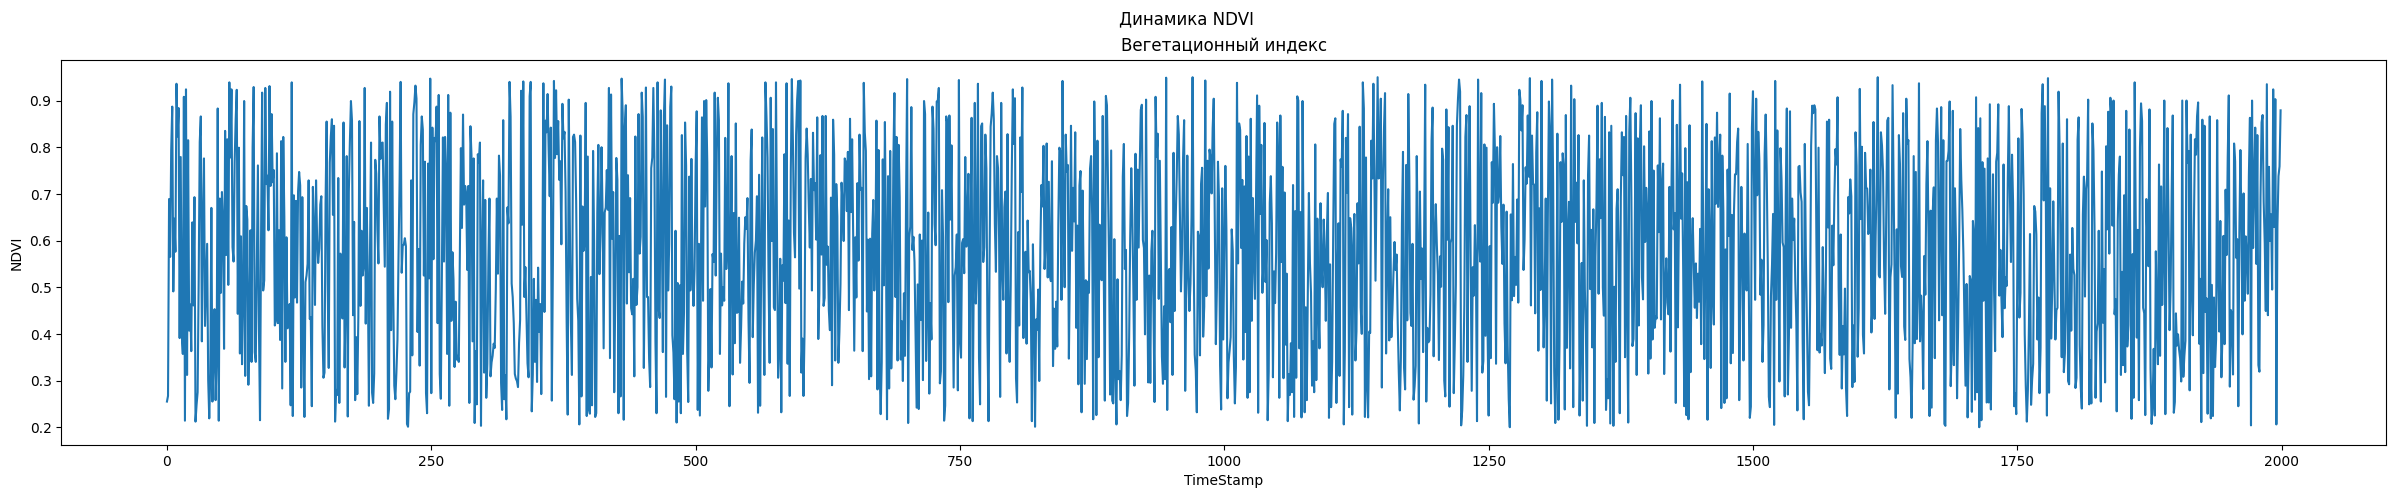

In [55]:
fig, ax = plt.subplots(1,1,figsize=(30, 5))
fig.suptitle('Динамика NDVI')

plot_assignation(ax, tsdf_c["NDVI_Index"], 'TimeStamp', 'NDVI','Вегетационный индекс')


### Выделение закономерных (неслучайных) составляющих временного ряда <a class="anchor" id="second-bullet"></a>

#### Разложения ряда на компоненты

Тренды, Сезонность, Остаточность


https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html


1) ***Тренд*** — общая долгосрочная тенденция изменения временного ряда, лежащая в основе его динамики.

2) ***Сезонная вариация*** — краткосрочное регулярно повторяющееся колебание значений временного ряда вокруг тренда.

3) ***Циклические колебания*** характеризуют так называемый цикл деловой активности, или экономический цикл, состоящий из экономического подъема, спада, депрессии и оживления. Этот цикл повторяется регулярно.

4) ***Остаточная вариация***, которая может быть двух видов:
**аномальная вариация** — неестественно большое отклонение временного ряда, которое оказывает воздействие на единичное наблюдение;
**случайная вариация** — малое отклонение, которое невозможно предвидеть. В долгосрочной перспективе случайные вариации могут с равной вероятностью как снизить, так и увеличить объем продаж.

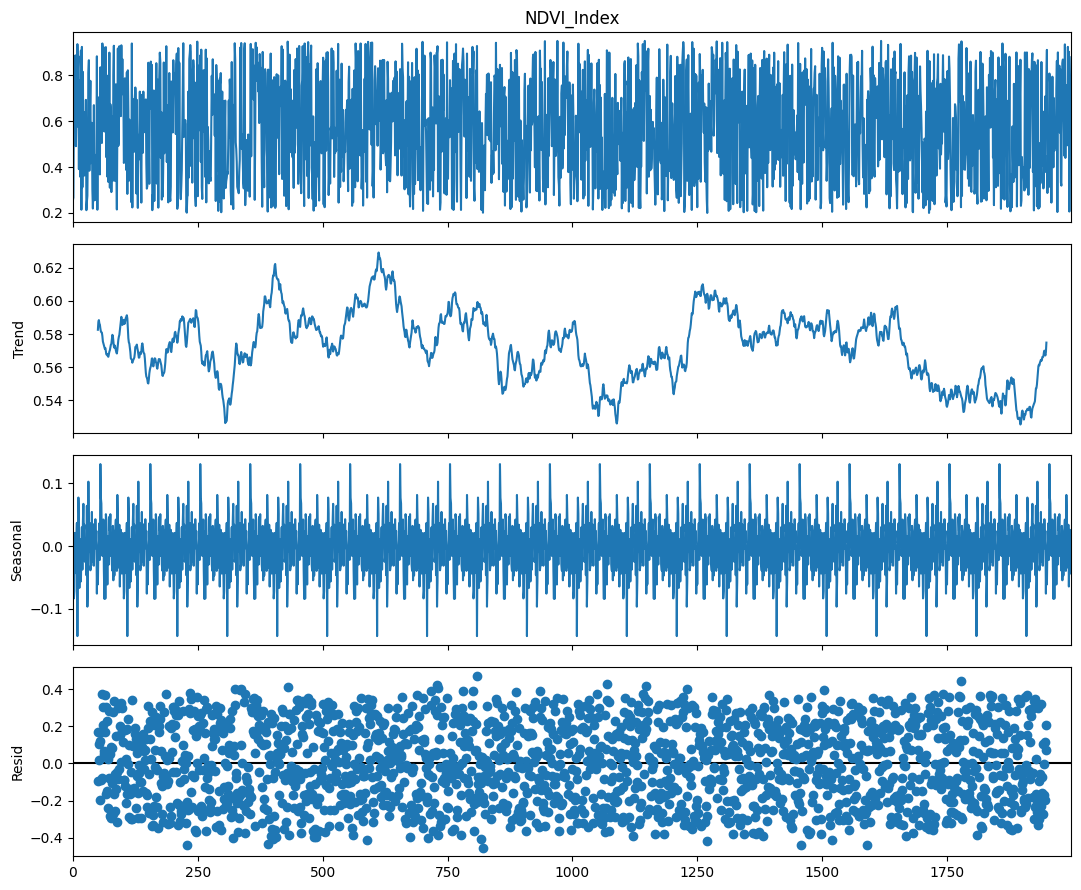

In [47]:
# импортируем функцию seasonal_decompose из statsmodels
# (то есть осуществляем декомпозицию сигнала/временного ряда)
from statsmodels.tsa.seasonal import seasonal_decompose

# задаем размер графика
from pylab import rcParams
rcParams['figure.figsize'] = 11, 9


decompose = seasonal_decompose(tsdf_c["NDVI_Index"], period=100)
decompose.plot()
plt.show()

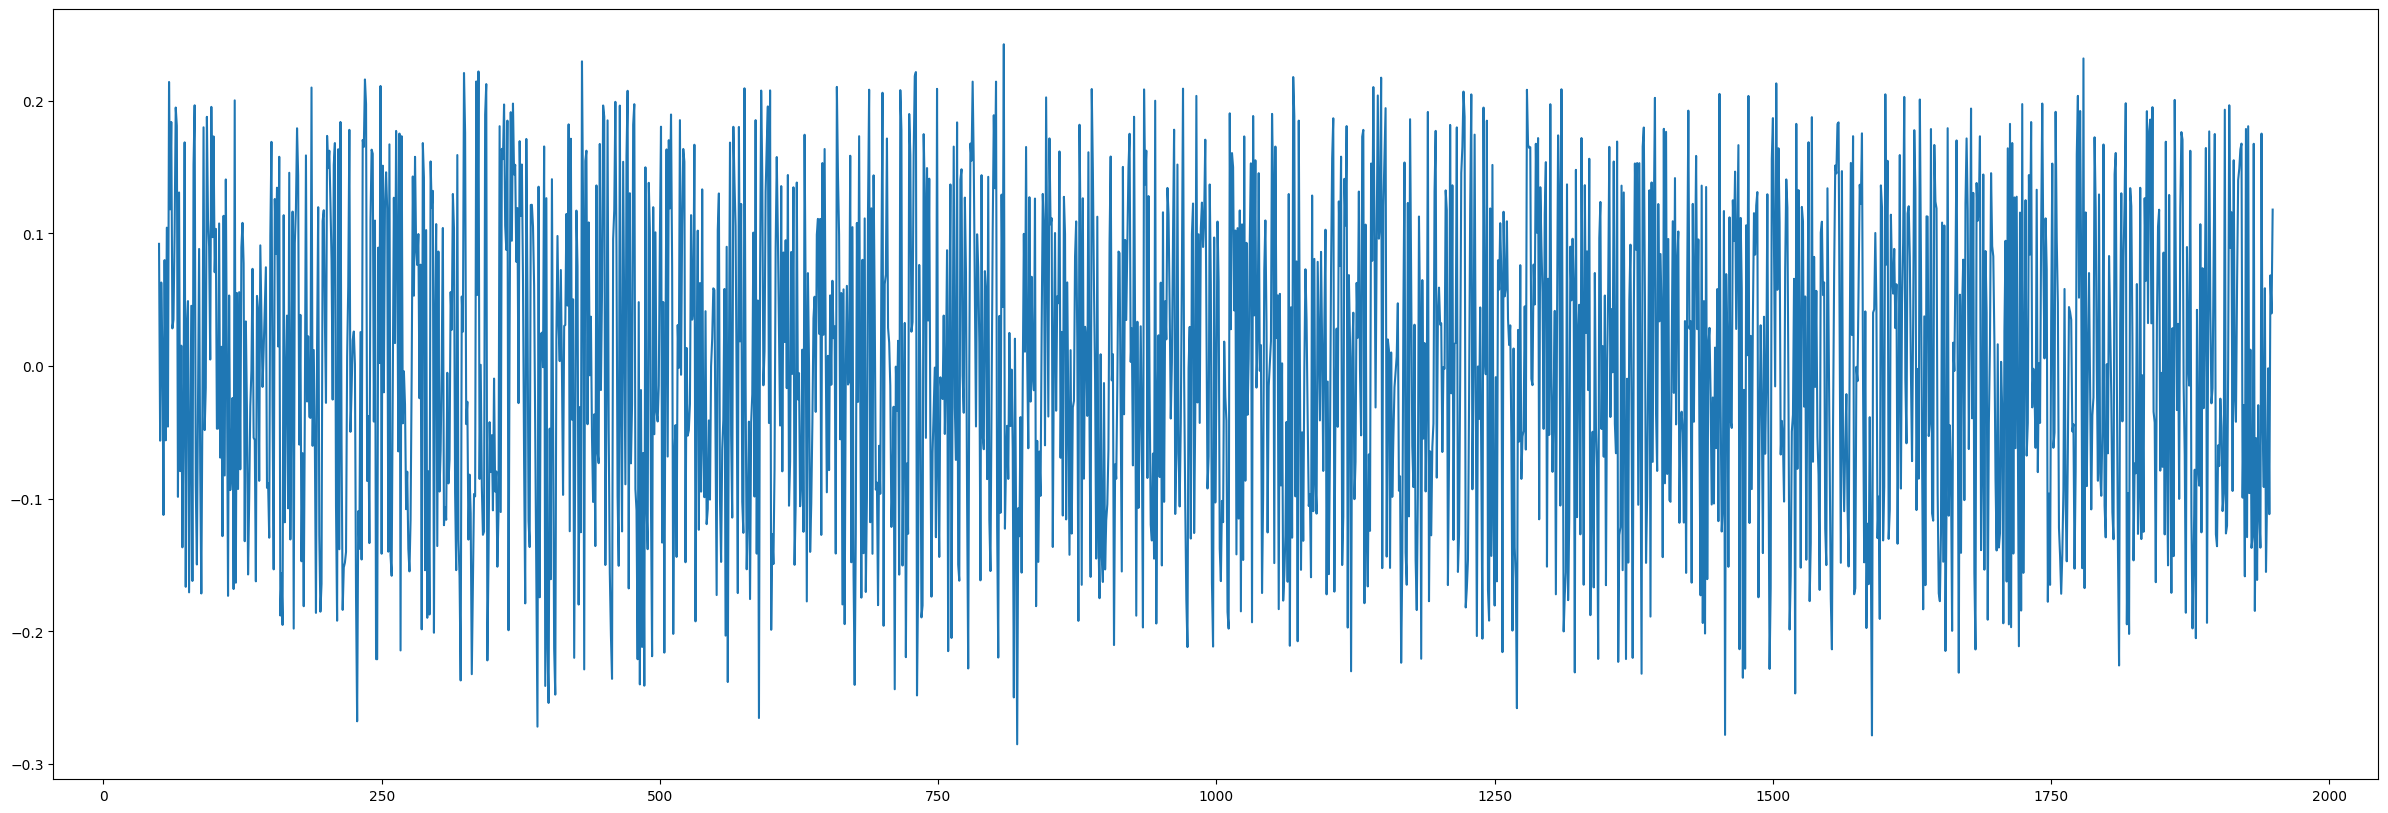

In [54]:
new_ps = decompose.trend*(decompose.seasonal+1)*decompose.resid

fig, axs = plt.subplots(figsize=(30, 10))
 
plt.plot(new_ps)
plt.show()

<Axes: >

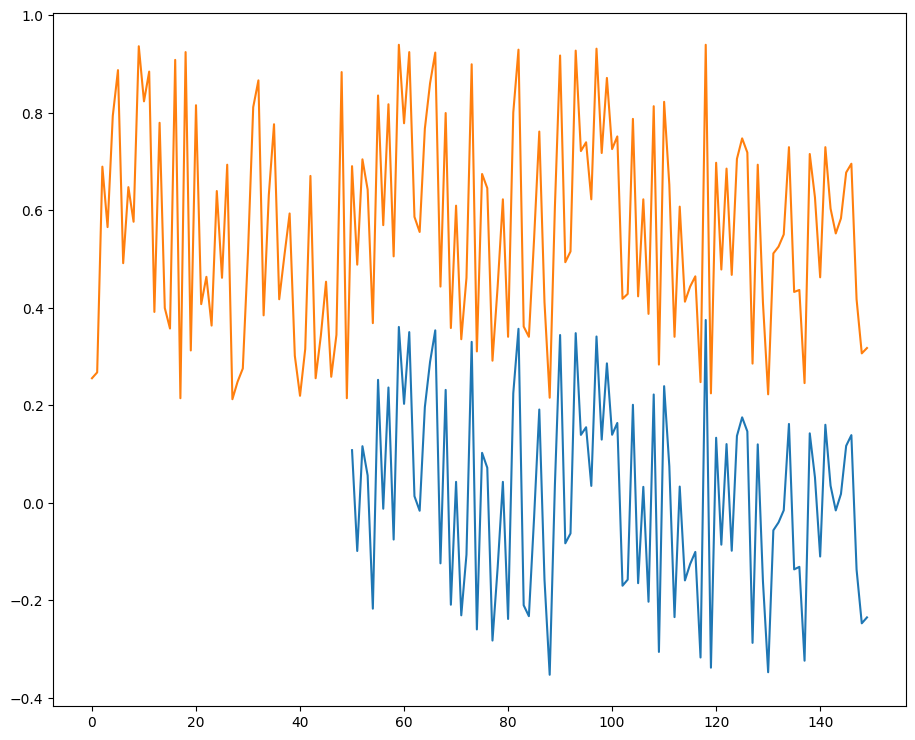

In [51]:
## удаляем компонент тренда из временного ряда...
NDVI = tsdf_c["NDVI_Index"] - decompose.trend
# ...и отрисовываем обработанный и исходный ряды
NDVI.head(150).plot()
tsdf_c["NDVI_Index"].head(150).plot()

In [19]:
# Ваш код здесь
# разложение ЭКГ по составляющим


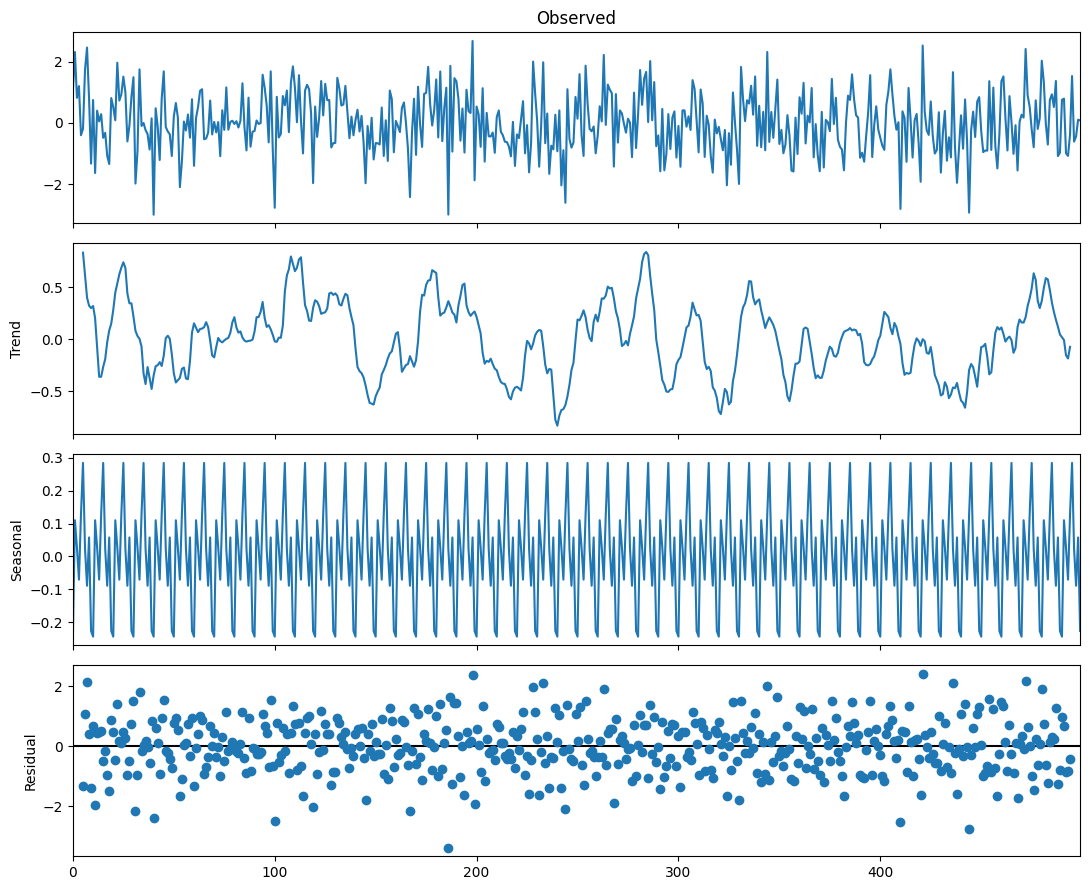

In [56]:
# разложение на составляюшие белый шум

import numpy as np
white_noise = np.random.normal(0,1, 500)

decompose = seasonal_decompose(white_noise, period=10, model="additive")
decompose.plot()
plt.show()

## Стационарный процесс  <a class="anchor" id="stacionary"></a>


Стационарный процесс - это случайный процесс, безусловное совместное распределение вероятностей которого не изменяется при сдвиге во времени. Следовательно, такие параметры, как среднее значение и дисперсия, также не меняются со временем, поэтому стационарные временные ряды легче прогнозировать.

Есть несколько способов установить, является ли временной ряд стационарным или нет, наиболее распространенными являются старая добрая визуализация, просмотр автокорреляции и выполнение статистических тестов.

Наиболее распространенным тестом является тест Дики-Фуллера (также называемый тест ADF), где нулевая гипотеза состоит в том, что временной ряд имеет единичный корень, другими словами, временной ряд не является стационарным.

Мы проверим, можно ли отвергнуть нулевую гипотезу, сравнив значение p с выбранным порогом (α), чтобы, если значение p меньше, мы могли отклонить нулевую гипотезу и предположить, что временной ряд с уверенностью является стационарным. уровень 1-α (технически мы просто не можем сказать, что это не так)

Временной ряд имеет единичный корень, или порядок интеграции один, если его первые разности образуют стационарный ряд. Это условие записывается как
$y_t\thicksim I(1)$ если ряд первых разностей $\triangle y_t=y_t-y_{t-1}$ является стационарным $\triangle y_t\thicksim I(0)$.

При помощи этого теста проверяют значение коэффициента $a$ в  авторегрессионном уравнении первого порядка AR(1)
$y_t=a\cdot y_{t-1}+\varepsilon_t,$
где $y_t$ — временной ряд, а $\varepsilon$— ошибка.

Если $a=1$, то процесс имеет единичный корень, в этом случае ряд $y_t$ не стационарен, является интегрированным временным рядом первого порядка $I(1)$. Если $|a|<1$, то ряд стационарный $I(0)$.


In [57]:
# импортируем функцию, описывающую тест Дики-Фуллера
from statsmodels.tsa.stattools import adfuller

In [58]:
# всю теорию, описанную выше, реализуем с помощью statsmodels для проверки
# временного ряда перевозок на стационарность

alpha = 0.05
name = "Вегетационный индекс"
ts = tsdf_c["NDVI_Index"]

print(f'Тест Дики-Фуллера ряда {name} :')
dftest = adfuller(ts, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dfoutput["p-value"] < alpha:
    print(f"Значение p меньше {alpha * 100}%. Ряд стационарный.")
else:
    print(f"Значение p больше {alpha*100}%. Ряд не стационарный.")

Тест Дики-Фуллера ряда Вегетационный индекс :
Test Statistic                  -30.170484
p-value                           0.000000
#Lags Used                        1.000000
Number of Observations Used    1998.000000
Critical Value (1%)              -3.433627
Critical Value (5%)              -2.862988
Critical Value (10%)             -2.567541
dtype: float64
Значение p меньше 5.0%. Ряд стационарный.


C:\Users\zuben\AppData\Local\Temp\ipykernel_27268\2480519492.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  dftest = adfuller(ts, autolag='AIC')


In [59]:
# проверьте на стационарность временной ряд с ЭКГ

### Тренд <a class="anchor" id="trend"></a>

Тренд - это компонент временного ряда, который представляет низкочастотные колебания во временном ряду, при этом высокочастотные и среднечастотные колебания отфильтрованы.

Как известно из лекции, существует три основных типа трендов.
1. Первым и самим очевидным типом тренда представляется тренд среднего, когда временной
ряд выглядит как колебания около медленно возрастающей или убывающей величины.

1. Второй тип трендов – это тренд дисперсии. В этом случае во времени меняется амплитуда
колебаний переменной.

1. Третий и более тонкий тип тренда, визуально не всегда наблюдаемый, – изменение
величины корреляции между текущим и предшествующим значениями ряда, т. е. тренд
автоковариации и автокорреляции.

Давайте напишем функцию, которая поможет нам понять тенденцию и движения временного ряда. Мы хотим видеть на графике некоторую скользящую статистику, такую как:

M скользящее среднее: невзвешенное среднее предыдущих n данных (также называемое скользящим средним).

Полосы Боллинджера: верхняя полоса в k раз на n-периодное стандартное отклонение выше скользящей средней и нижняя полоса в k раз на стандартное отклонение N ниже.

C:\Users\zuben\AppData\Local\Temp\ipykernel_27268\1110318620.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g" (-> color=(0.0, 0.5, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(rolling_mean, 'g', label='MA'+str(window),


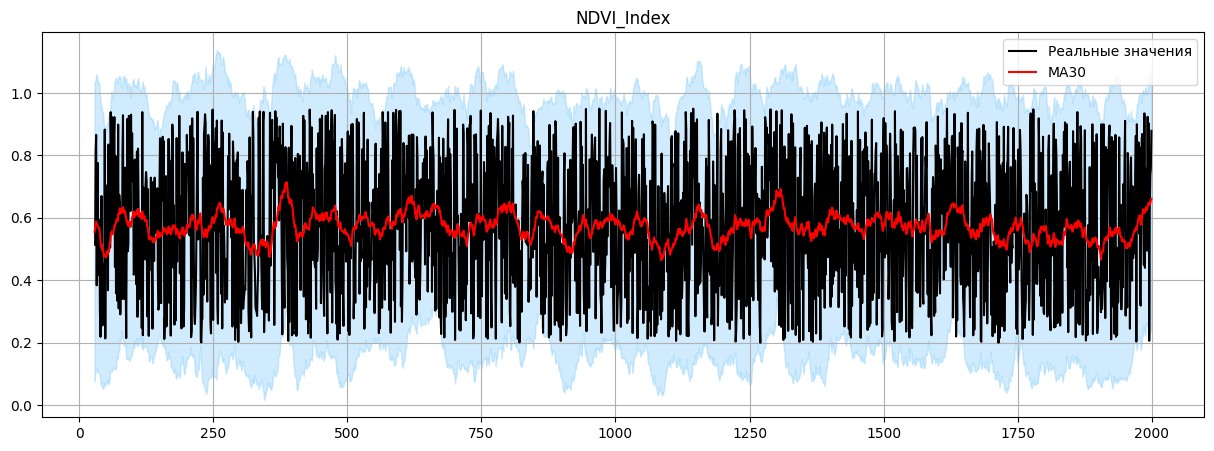

In [60]:
# указываем размер окна
window = 30

# вычисляем скользящее среднее и стандартное отклонение
rolling_mean = ts.rolling(window=window).mean()
rolling_std = ts.rolling(window=window).std()

plt.figure(figsize=(15,5))
plt.title(ts.name)
plt.plot(ts[window:], label='Реальные значения', color="black")

# отрисовываем скользящее среднее
plt.plot(rolling_mean, 'g', label='MA'+str(window),
             color="red")

# отрисовываем верхний и нижний интервалы
lower_bound = rolling_mean - (1.96 * rolling_std)
upper_bound = rolling_mean + (1.96 * rolling_std)

plt.fill_between(x=ts.index, y1=lower_bound, y2=upper_bound,
                 color='lightskyblue', alpha=0.4)
plt.legend(loc='best')
# показываем сетку на графике
plt.grid(True)
plt.show()


### Сезонность  <a class="anchor" id="season"></a>

Существует несколько подходов к анализу структуры временных рядов, содержащих сезонные или циклические колебания. Простейший подход – расчет значений сезонной компоненты методом скользящей средней и построение аддитивной или мультипликативной модели временного ряда.

Выбор аддитивной или мультипликативной модели проводится на основе анализа структуры сезонных колебани. Если амплитуда колебаний приблизительно постоянна, строят аддитивную модель временного ряда, в которой
значения сезонной компоненты предполагаются постоянными для различных циклов.

Если амплитуда сезонных колебаний возрастает или уменьшается, строят мультипликативную модель
временного ряда, которая ставит уровни ряда в зависимость от значений сезонной компоненты.

Построение аддитивной и мультипликативной моделей сводится к расчету значений $T$, $S$ и $E$ для
каждого уровня ряда.


### Автокорреляция и коррелограмма <a class="anchor" id="autocor"></a>



In [61]:
import statsmodels.tsa.api as smt

<Figure size 1200x700 with 0 Axes>

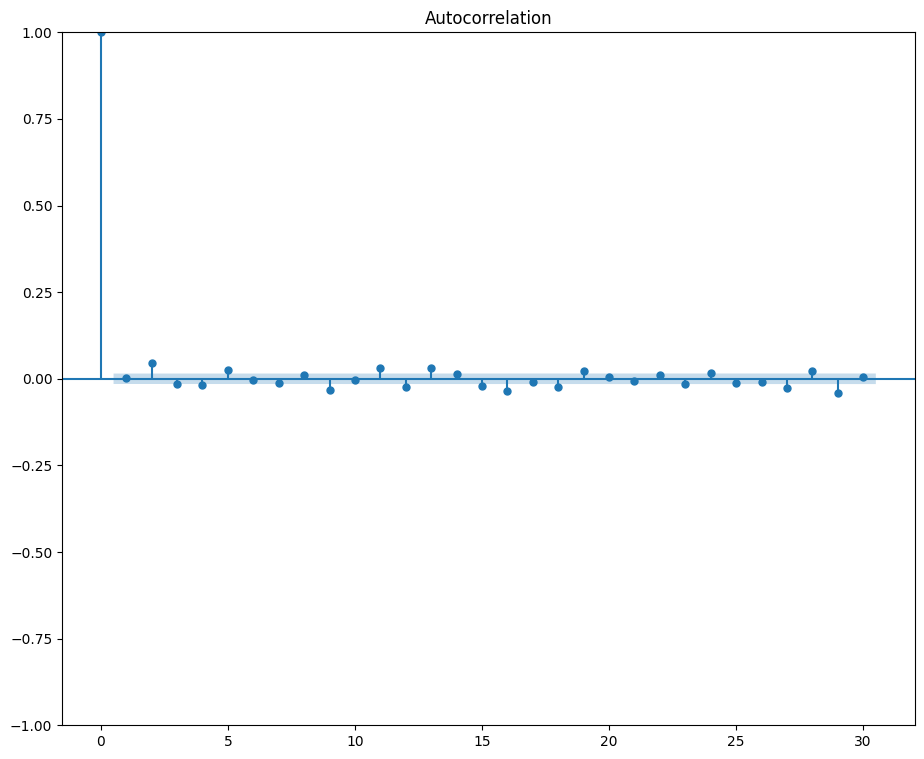

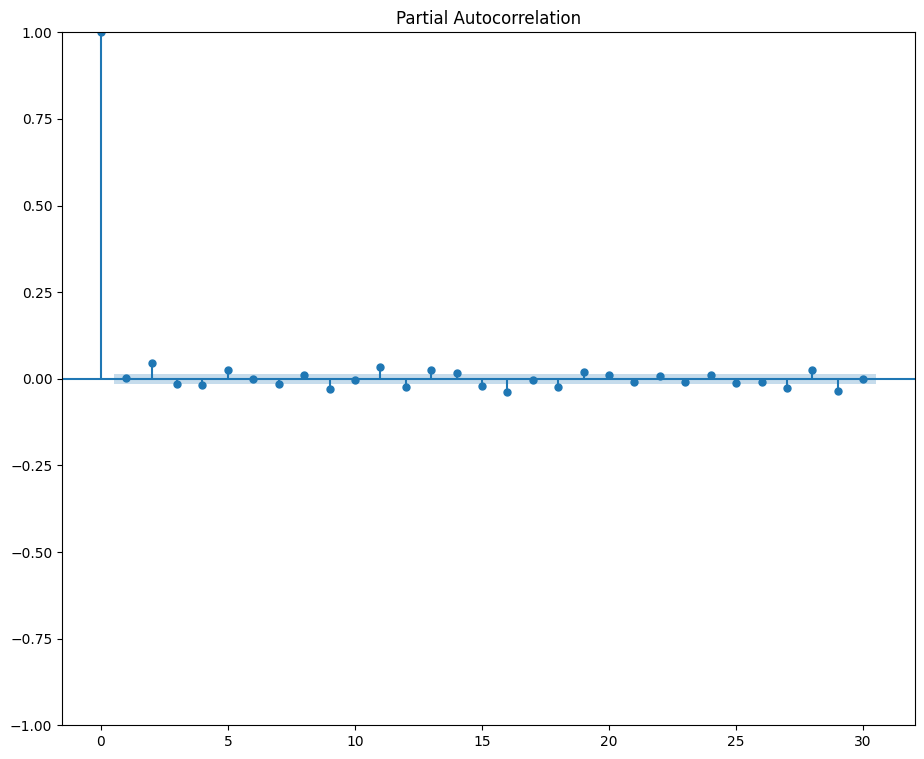

In [63]:
ts = tsdf_c["NDVI_Index"]


fig = plt.figure(figsize=(12, 7))
# рисуем автокорреляционную функцию
# 
# изображение отрисовывается с запаздываниями по горизонтали и корреляциями по
# вертикали
ac_plot = smt.graphics.plot_acf(ts, lags=30, alpha=0.5)

# есть также функция отрисовки частичной автокорреляции
pac_plot = smt.graphics.plot_pacf(ts, lags=30, alpha=0.5)

# Частичная автокорреляция (Partial Autocorrelation) — это краткая
# характеристика взаимосвязи между наблюдением во временном ряду и наблюдениями
# на предыдущем отрезке времени, когда влияние малой задержки устранено.
# Автокорреляция состоит как из прямой, так и из косвенной корреляции.

Можно все эти графики красиво отрисовать

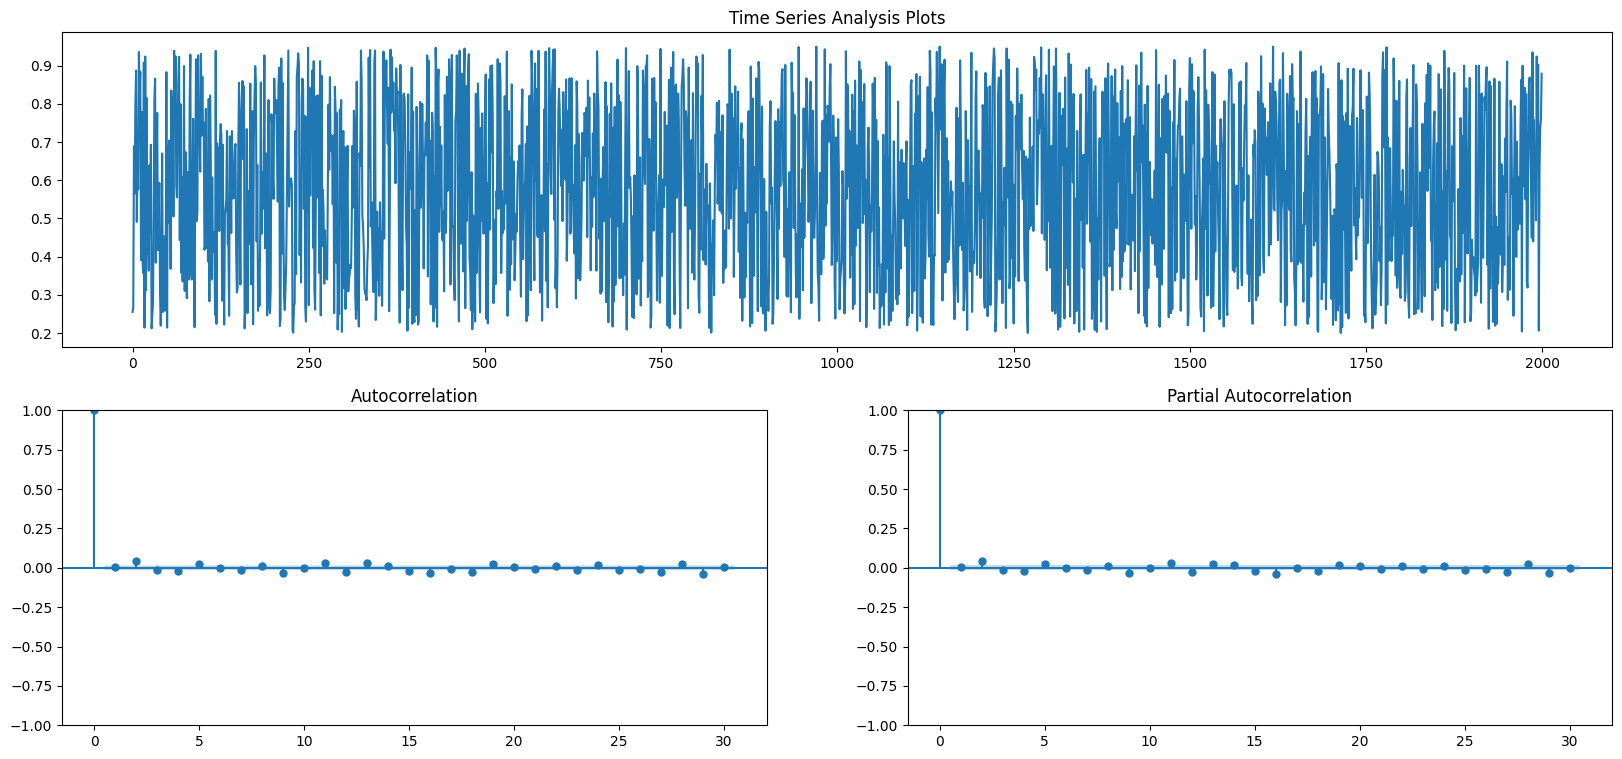

In [64]:
fig = plt.figure(figsize=(20, 9))
layout = (2, 2)
ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
acf_ax = plt.subplot2grid(layout, (1, 0))
pacf_ax = plt.subplot2grid(layout, (1, 1))

ts.plot(ax=ts_ax)
ts_ax.set_title('Time Series Analysis Plots')
smt.graphics.plot_acf(ts, lags=30, ax=acf_ax, alpha=0.5)
smt.graphics.plot_pacf(ts, lags=30, ax=pacf_ax, alpha=0.5)
None